In [1]:
import sys
print(sys.executable)
print(sys.version)

D:\SEMESTER 07\Digital Image Processing\project\PRODEXA\venv311\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [2]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

sys.path.append(os.path.abspath(os.path.join("..")))

from src.preprocessing import preprocess_image
from src.segmentation import segment_products
from src.detection import detect_products, draw_detections, crop_products, print_detection_summary
from src.classification import (
    extract_features, extract_features_batch, load_training_data,
    load_training_data_segmented, train_classifier, evaluate_classifier,
    save_model, load_model, classify_crop, classify_detections
)

MANIFEST_PATH = "../data/dataset_subset.txt"
PROCESSED_DIR = "../data/processed"
MODEL_DIR = "../models"
CHECKOUT_DIR = "../data/checkout_easy"
OUTPUT_DIR = "../outputs"

In [3]:
X, y, filenames = load_training_data(MANIFEST_PATH, PROCESSED_DIR, batch_size=32)

Extracting CNN features for 2550 images...
Loading MobileNetV2 (pretrained on ImageNet) as feature extractor...
Feature extractor ready.


In [4]:
print(f"Loaded {X.shape[0]} samples, {X.shape[1]}-dim CNN features each")
print(f"Categories: {sorted(set(y))}")

Loaded 2550 samples, 1280-dim CNN features each
Categories: [np.str_('alcohol'), np.str_('candy'), np.str_('canned_food'), np.str_('chocolate'), np.str_('dessert'), np.str_('dried_food'), np.str_('dried_fruit'), np.str_('drink'), np.str_('gum'), np.str_('instant_drink'), np.str_('instant_noodles'), np.str_('milk'), np.str_('personal_hygiene'), np.str_('puffed_food'), np.str_('seasoner'), np.str_('stationery'), np.str_('tissue')]


In [5]:
model, label_encoder, X_test, y_test, y_pred = train_classifier(X, y, test_size=0.2, seed=42)

print(f"Train size: {len(X) - len(X_test)}, Test size: {len(X_test)}")

Train size: 2040, Test size: 510


In [6]:
accuracy = evaluate_classifier(y_test, y_pred, label_encoder)

if accuracy >= 0.80:
    print(f"\n✅ Meets assignment requirement (≥80% accuracy): {accuracy:.2%}")
else:
    print(f"\n⚠️ Below 80% target: {accuracy:.2%} — see confusion matrix below to diagnose")

Accuracy: 0.7882

Classification Report:
                  precision    recall  f1-score   support

         alcohol       0.90      0.87      0.88        30
           candy       0.56      0.73      0.64        30
     canned_food       0.76      0.97      0.85        30
       chocolate       0.70      0.70      0.70        30
         dessert       0.67      0.67      0.67        30
      dried_food       0.82      0.93      0.88        30
     dried_fruit       0.92      0.73      0.81        30
           drink       0.93      0.90      0.92        30
             gum       0.67      1.00      0.80        30
   instant_drink       0.86      0.60      0.71        30
 instant_noodles       0.92      0.77      0.84        30
            milk       0.76      0.97      0.85        30
personal_hygiene       0.88      0.73      0.80        30
     puffed_food       0.84      0.90      0.87        30
        seasoner       0.79      0.37      0.50        30
      stationery       0.92   

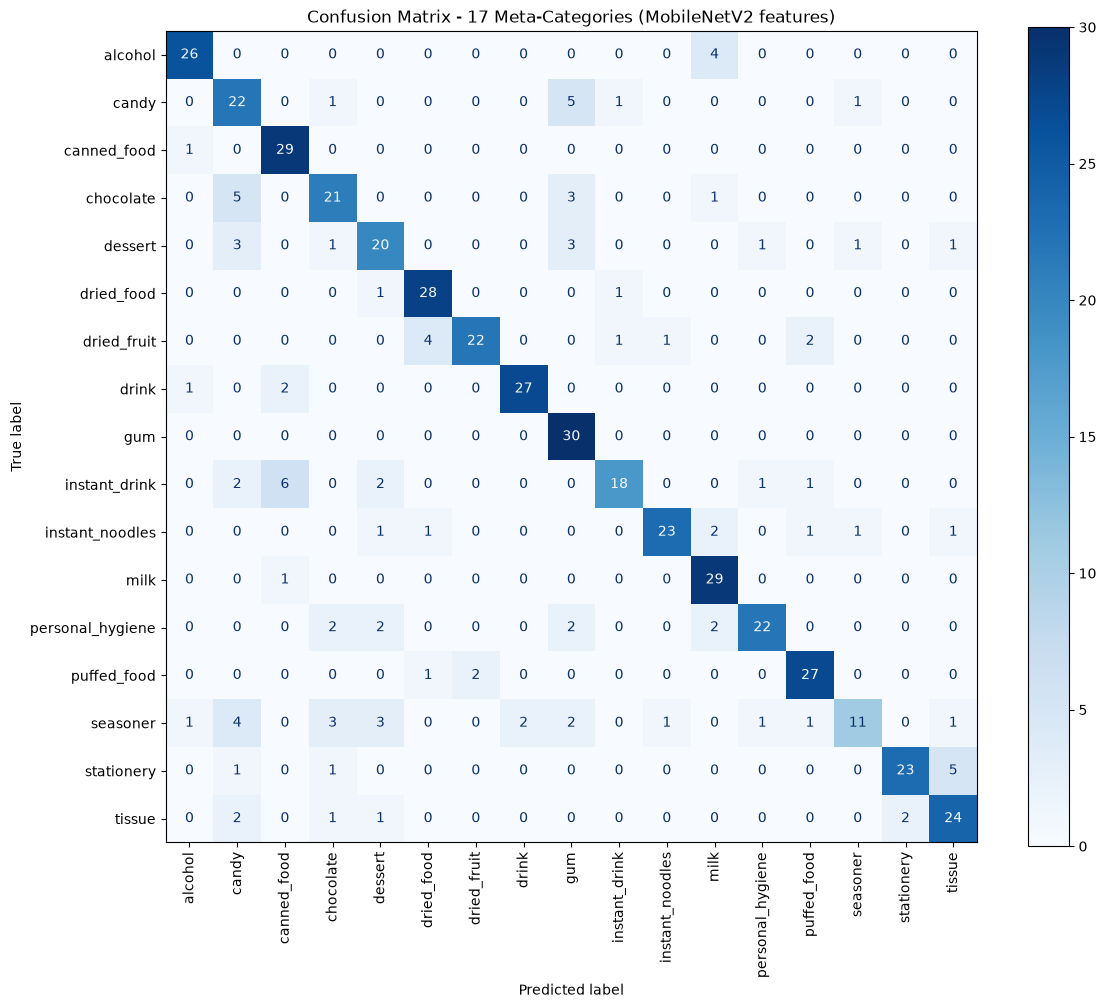

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=90,
    ax=ax,
    cmap="Blues"
)
plt.title("Confusion Matrix - 17 Meta-Categories (MobileNetV2 features)")
plt.tight_layout()
plt.show()

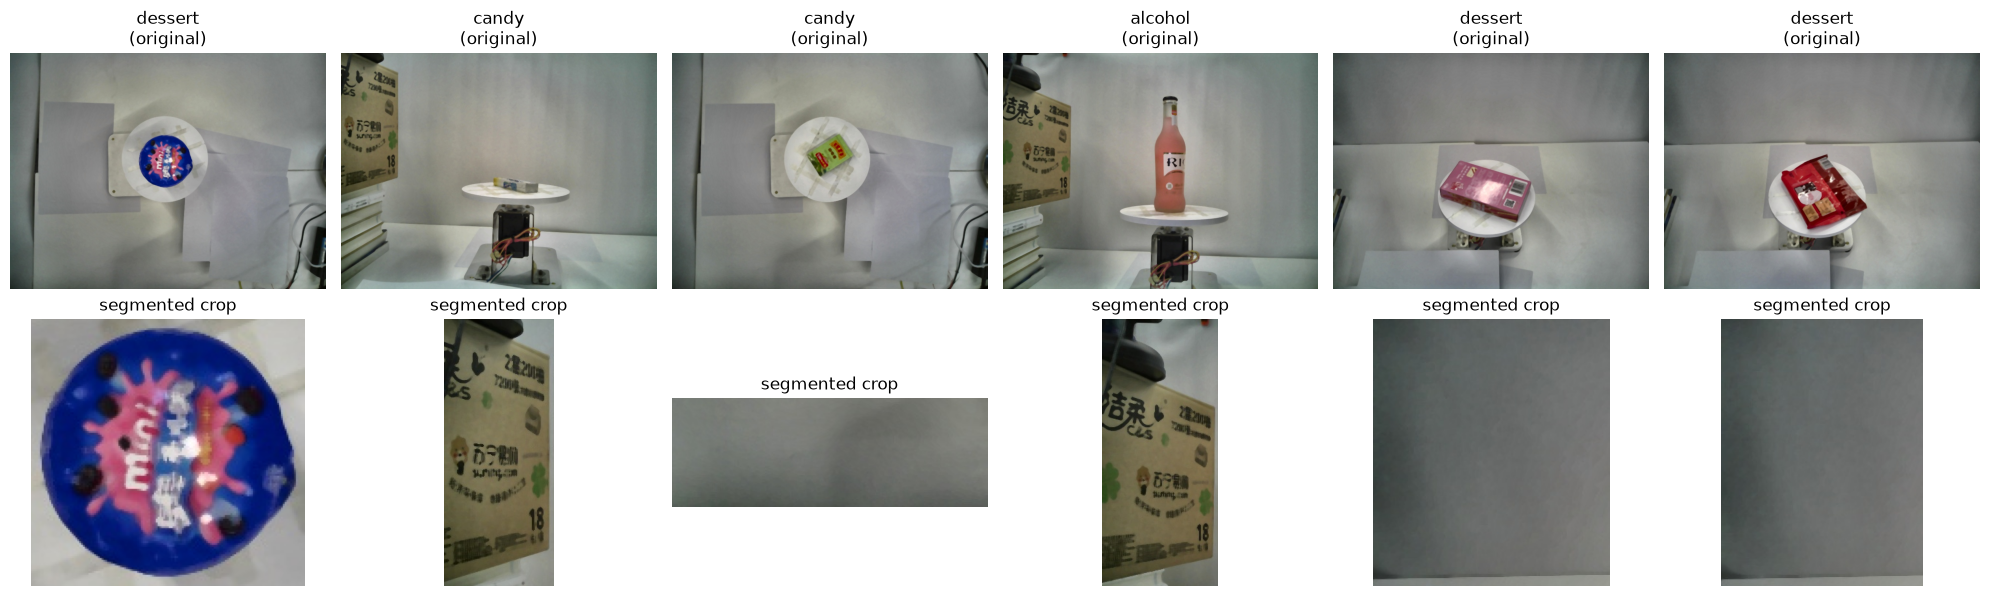

In [8]:
import random

with open(MANIFEST_PATH, "r") as f:
    lines = [l.strip().split("\t") for l in f]

sample_lines = random.sample(lines, 6)

fig, axes = plt.subplots(2, 6, figsize=(20, 6))
for i, (filename, supercat, _) in enumerate(sample_lines):
    image = cv2.imread(os.path.join(PROCESSED_DIR, filename))
    seg_result = segment_products(image)
    detections = detect_products(image, seg_result)

    axes[0, i].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f"{supercat}\n(original)")
    axes[0, i].axis("off")

    if detections:
        best_det = max(detections, key=lambda d: d["area"])
        crop = crop_products(image, [best_det])[0][1]
        axes[1, i].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        axes[1, i].set_title("segmented crop")
    else:
        axes[1, i].set_title("NO DETECTION")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {
    "C": [1, 10, 50, 100],
    "gamma": ["scale", 0.001, 0.01, 0.1]
}

grid = GridSearchCV(SVC(kernel="rbf", probability=True, random_state=42),
                     param_grid, cv=3, n_jobs=-1, verbose=2)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

model = grid.best_estimator_
y_pred = model.predict(X_test_scaled)

from src.classification import evaluate_classifier
evaluate_classifier(y_test, y_pred, label_encoder)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


D:\SEMESTER 07\Digital Image Processing\project\PRODEXA\venv311\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Best params: {'C': 10, 'gamma': 'scale'}
Best CV score: 0.8274509803921569
Accuracy: 0.9020

Classification Report:
                  precision    recall  f1-score   support

         alcohol       0.97      0.93      0.95        30
           candy       0.72      0.87      0.79        30
     canned_food       0.94      1.00      0.97        30
       chocolate       0.72      0.77      0.74        30
         dessert       0.69      0.80      0.74        30
      dried_food       0.93      0.93      0.93        30
     dried_fruit       1.00      0.93      0.97        30
           drink       0.93      0.93      0.93        30
             gum       0.91      1.00      0.95        30
   instant_drink       0.96      0.87      0.91        30
 instant_noodles       0.97      0.97      0.97        30
            milk       0.91      0.97      0.94        30
personal_hygiene       1.00      0.93      0.97        30
     puffed_food       0.97      0.97      0.97        30
        seaso

0.9019607843137255

In [1]:
save_model(model, label_encoder, scaler, model_dir=MODEL_DIR)

NameError: name 'save_model' is not defined